# 1. 데이터 로드 및 병합
- 7개의 원본 CSV를 로드하고 하나의 Master DataFrame으로 병합합니다.

In [1]:
import pandas as pd
import os

DATA_DIR = "data"

def load_and_merge():
    files = {
        '기본정보': '기본정보.csv', '면적정보': '면적정보.csv', '시설정보': '시설정보.csv',
        '운영정보': '운영정보.csv', '위치정보': '위치정보.csv', '장기수선': '장기수선.csv', '관리비': '관리비.csv'
    }
    dfs = {}
    for name, filename in files.items():
        path = os.path.join(DATA_DIR, filename)
        try:
            dfs[name] = pd.read_csv(path, encoding='utf-8')
        except UnicodeDecodeError:
            dfs[name] = pd.read_csv(path, encoding='cp949')

    if '면적정보' in dfs:
        area_df = dfs['면적정보']

        # 데이터 오류 수정 1: A13881302 단지의 한 행이 주거전용면적(세부)=84083.00으로 기입돼 있음.
        # 같은 단지의 다른 행(84.83)과 비교하면 소수점이 빠지며 자릿수가 잘못 기입된 오류로 판단해,
        # 해당 행의 세대수(1세대)를 84.83 행에 합산하고 오류 행은 제거한다.
        wrong_row = (area_df['단지코드'] == 'A13881302') & (area_df['주거전용면적(세부)'] == 84083.00)
        target_row = (area_df['단지코드'] == 'A13881302') & (area_df['주거전용면적(세부)'] == 84.83)
        area_df.loc[target_row, '세대수'] += area_df.loc[wrong_row, '세대수'].sum()
        area_df = area_df.loc[~wrong_row].reset_index(drop=True)

        # 데이터 오류 수정 2: 위 수정 후에도 A13881302의 주거전용면적(단지합계)=109728.83은
        # 관리비부과면적(33471.01)보다 3배 이상 크고(전용면적이 관리비부과면적보다 큰 것은 물리적으로 비정상),
        # 세부 행(전용면적 x 세대수)의 합(약 25,730.66)과도 맞지 않아 오류로 판단한다.
        # 정확한 원본 값을 확인할 방법이 없어, 세부 행 기준 합으로 보수적으로 대체한다.
        mask_a13881302 = area_df['단지코드'] == 'A13881302'
        corrected_total_area = (
            area_df.loc[mask_a13881302, '주거전용면적(세부)'] * area_df.loc[mask_a13881302, '세대수']
        ).sum()
        area_df.loc[mask_a13881302, '주거전용면적(단지합계)'] = corrected_total_area

        dfs['면적정보'] = area_df.drop_duplicates(subset=['단지코드']).drop(columns=['주거전용면적(세부)', '세대수'], errors='ignore')

    static_df = dfs['기본정보']
    for table_name in ['면적정보', '시설정보', '운영정보', '위치정보']:
        df_to_merge = dfs[table_name]
        cols_to_use = [col for col in df_to_merge.columns if col not in static_df.columns or col == '단지코드']
        static_df = pd.merge(static_df, df_to_merge[cols_to_use], on='단지코드', how='left')
    
    ts_df = dfs['관리비']
    repair_df = dfs['장기수선']
    join_keys = ['단지코드', '발생년월(YYYYMM)']
    cols_to_use = [col for col in repair_df.columns if col not in ts_df.columns or col in join_keys]
    ts_df = pd.merge(ts_df, repair_df[cols_to_use], on=join_keys, how='left')
    
    raw_master_df = pd.merge(ts_df, static_df, on='단지코드', how='left')
    return raw_master_df

raw_master_df = load_and_merge()
print(f"병합 완료된 원본 데이터 크기: {raw_master_df.shape}")
raw_master_df.head()

병합 완료된 원본 데이터 크기: (147240, 87)


,단지코드,발생년월(YYYYMM),공용관리비계,인건비,제사무비,제세공과금,피복비,교육훈련비,차량유지비,그밖의부대비용,...,경비관리-인원,경비관리-계약업체,청소관리-관리방식,청소관리-인원,청소관리-계약업체,음식물 처리방법,소독관리-관리방식,소독관리-계약업체,위도,경도
0,A11007001,202101,53343583.0,21552672,248500.0,65740,0,0,0,341860,...,4.0,에스원,위탁관리,4,좋은서비스,차량수거방식,위탁관리,좋은서비스,37.573567,126.972151
1,A11007001,202102,53189158.0,21552614,248100.0,70920,0,71000,0,326160,...,4.0,에스원,위탁관리,4,좋은서비스,차량수거방식,위탁관리,좋은서비스,37.573567,126.972151
2,A11007001,202103,53228835.0,21552616,228500.0,53530,0,50000,0,711840,...,4.0,에스원,위탁관리,4,좋은서비스,차량수거방식,위탁관리,좋은서비스,37.573567,126.972151
3,A11007001,202104,51995807.0,20485440,243900.0,54170,0,50000,0,315660,...,4.0,에스원,위탁관리,4,좋은서비스,차량수거방식,위탁관리,좋은서비스,37.573567,126.972151
4,A11007001,202105,52384391.0,20494660,231100.0,62900,0,0,0,398410,...,4.0,에스원,위탁관리,4,좋은서비스,차량수거방식,위탁관리,좋은서비스,37.573567,126.972151


## 1-1. 세대수 데이터 보정

`기본정보.csv`의 `세대수`와 `면적정보.csv`(평형별 세대수의 단지 합계)가 서로 다른 단지를 전수 조사한 결과 **83개 단지**에서 불일치가 확인됐습니다(양방향 모두 존재 — 기본정보가 더 작은 경우와 더 큰 경우가 섞여 있음).

외부 참조자료(`서울시 공동주택 아파트 정보(위도경도 포함)` CSV, 아파트 단지별 상세 정보를 담은 공개 자료의 `k-전체세대수` 컬럼)로 교차 검증해, **79개 단지**는 참조자료 값으로 `세대수`를 보정합니다. 나머지 4개 단지 중 3개(`A13528105` 개포1차2차우성, `A10027289` 센트라스, `A13402304` 천호태영임대)는 참조자료 파일에 해당 단지 행 자체가 없어 값을 가져오지 못했던 것으로 확인되어, 정확한 세대수(각각 1,140세대·2,529세대·649세대)를 별도로 확인해 보정합니다(총 **82개 단지** 보정). 나머지 1개 단지(`A13527017`)는 여전히 참조자료 값이 없어 원본을 유지합니다(추후 별도 확인 필요).

또한 `면적정보.csv`에서 `A13881302`(거여현대3차) 단지에 두 가지 오류를 확인해 위 코드 셀에서 처리했습니다.
1. 한 행이 `주거전용면적(세부)=84083.00`으로 기입돼 있던 것 — 같은 단지의 다른 행(`84.83`)과 비교했을 때 소수점이 빠지며 자릿수가 잘못 기입된 오류로 판단해, 해당 행의 세대수(1세대)를 `84.83` 행에 합산하고 오류 행은 제거했습니다.
2. 위 수정 후에도 `주거전용면적(단지합계)=109728.83`이 `관리비부과면적`(33471.01)보다 3배 이상 크고(전용면적이 관리비부과면적보다 큰 것은 물리적으로 비정상) 세부 행 기준 합(약 25,730.66)과도 크게 어긋나 있어 별도 오류로 판단, 정확한 원본 값을 확인할 방법이 없어 세부 행 기준 합으로 보수적으로 대체했습니다.

In [2]:
# 세대수 보정 매핑: 단지코드 -> 정확한 세대수
# 출처: 서울시 공동주택 아파트 정보(위도경도 포함) 참조자료의 `k-전체세대수` 컬럼(79개) +
#      참조자료에 행 자체가 없어 별도로 확인한 3개 단지(A13528105, A10027289, A13402304)
# 기본정보.csv 세대수와 면적정보.csv 세대수 합계가 불일치한 83개 단지 중, 82개 단지 포함
HOUSEHOLD_COUNT_CORRECTIONS = {
    'A10023788': 276, 'A10023815': 249, 'A10024408': 306, 'A10024891': 913,
    'A10025013': 959, 'A10026004': 607, 'A10026036': 927, 'A10026710': 208,
    'A10026748': 1976, 'A10027851': 940, 'A10028042': 245, 'A10028172': 716,
    'A10028201': 182, 'A10045302': 3118, 'A10086301': 286, 'A10095501': 297,
    'A12009304': 554, 'A12009305': 768, 'A12201102': 300, 'A12275501': 254,
    'A13003406': 741, 'A13009002': 1224, 'A13009206': 445, 'A13070101': 190,
    'A13186305': 858, 'A13188406': 345, 'A13203408': 690, 'A13276417': 489,
    'A13307002': 457, 'A13475001': 191, 'A13484003': 277, 'A13522006': 1163,
    'A13522008': 2565, 'A13528004': 2436, 'A13528005': 372, 'A13552001': 1513,
    'A13572601': 239, 'A13582002': 548, 'A13590204': 826, 'A13593908': 1623,
    'A13607302': 354, 'A13615002': 453, 'A13679902': 201, 'A13703011': 256,
    'A13707006': 293, 'A13792001': 2390, 'A13812004': 249, 'A13812005': 889,
    'A13822902': 555, 'A13872503': 523, 'A13879102': 3930, 'A13880406': 839,
    'A13881204': 672, 'A13977913': 2634, 'A14070302': 589, 'A14085002': 554,
    'A14086001': 578, 'A14319012': 1177, 'A15003001': 271, 'A15005402': 826,
    'A15007002': 233, 'A15089421': 1584, 'A15101101': 688, 'A15101507': 960,
    'A15183001': 387, 'A15210105': 252, 'A15303103': 233, 'A15383308': 1226,
    'A15383702': 786, 'A15383905': 640, 'A15703313': 1670, 'A15722010': 442,
    'A15776715': 1146, 'A15780705': 1998, 'A15780806': 2412, 'A15785612': 1000,
    'A15805503': 1382, 'A15882104': 183, 'A41279927': 335,
    'A13528105': 1140, 'A10027289': 2529, 'A13402304': 649,
}

def correct_household_counts(df, correction_map=HOUSEHOLD_COUNT_CORRECTIONS):
    df = df.copy()
    corrected = df['단지코드'].map(correction_map)
    n_complexes = df.loc[corrected.notna(), '단지코드'].nunique()
    df['세대수'] = corrected.fillna(df['세대수'])
    print(f"세대수 보정 적용: {n_complexes}개 단지")
    return df

raw_master_df = correct_household_counts(raw_master_df)
raw_master_df[raw_master_df['단지코드'].isin(HOUSEHOLD_COUNT_CORRECTIONS)][['단지코드', '세대수']].drop_duplicates('단지코드').head()

세대수 보정 적용: 82개 단지


,단지코드,세대수
324,A10086301,286.0
348,A10028201,182.0
432,A10045302,3118.0
540,A10095501,297.0
624,A10023788,276.0


# 2. 데이터 전처리
- 2-1. 결측치 처리
- 2-2. 칼럼 삭제
- 2-3. 파생변수 생성
- 2-4. 다중공선성 확인 (VIF)

## 2-1. 결측치 처리
- `경비관리-인원`(0.49%, 12개 단지) 결측치를 **세대수 사분위 구간 × 관리방식 그룹 중앙값**으로 대치합니다.
- 그 외 관리비/시설 항목의 0값들(난방비, 임대세대수 등)은 결측이 아니라 정당한 값(구조적 0·이벤트성 0)으로 판단되어 별도 처리하지 않습니다.
- 근거 및 검증 과정: `문서/작업과정/결측치_처리_점검_20260826.md`

In [3]:
def handle_missing_values(df):
    df = df.copy()
    missing_codes = df.loc[df['경비관리-인원'].isna(), '단지코드'].unique()

    complexes = df.drop_duplicates('단지코드').copy()
    q1, q2, q3 = complexes['세대수'].quantile([.25, .5, .75])

    def bucket_size(x):
        if x <= q1:
            return '소형'
        if x <= q2:
            return '중소형'
        if x <= q3:
            return '중대형'
        return '대형'

    complexes['세대수구간'] = complexes['세대수'].apply(bucket_size)
    df = df.merge(complexes[['단지코드', '세대수구간']], on='단지코드', how='left')

    group_median = (
        df.dropna(subset=['경비관리-인원'])
        .groupby(['세대수구간', '관리방식'])['경비관리-인원']
        .median()
    )

    def impute_guard_staff(row):
        if pd.notna(row['경비관리-인원']):
            return row['경비관리-인원']
        key = (row['세대수구간'], row['관리방식'])
        if key in group_median.index:
            return group_median.loc[key]
        return group_median.loc[row['세대수구간']].median()  # fallback: 관리방식 무시하고 세대수구간 전체 중앙값

    df['경비관리-인원'] = df.apply(impute_guard_staff, axis=1)
    df = df.drop(columns=['세대수구간'])

    print(f"결측치 대치 완료: {len(missing_codes)}개 단지의 경비관리-인원 결측을 그룹 중앙값으로 대치")
    print(f"대치 후 남은 결측 수: {df['경비관리-인원'].isna().sum()}")
    return df

raw_master_df = handle_missing_values(raw_master_df)
raw_master_df.head()

결측치 대치 완료: 12개 단지의 경비관리-인원 결측을 그룹 중앙값으로 대치
대치 후 남은 결측 수: 0


,단지코드,발생년월(YYYYMM),공용관리비계,인건비,제사무비,제세공과금,피복비,교육훈련비,차량유지비,그밖의부대비용,...,경비관리-인원,경비관리-계약업체,청소관리-관리방식,청소관리-인원,청소관리-계약업체,음식물 처리방법,소독관리-관리방식,소독관리-계약업체,위도,경도
0,A11007001,202101,53343583.0,21552672,248500.0,65740,0,0,0,341860,...,4.0,에스원,위탁관리,4,좋은서비스,차량수거방식,위탁관리,좋은서비스,37.573567,126.972151
1,A11007001,202102,53189158.0,21552614,248100.0,70920,0,71000,0,326160,...,4.0,에스원,위탁관리,4,좋은서비스,차량수거방식,위탁관리,좋은서비스,37.573567,126.972151
2,A11007001,202103,53228835.0,21552616,228500.0,53530,0,50000,0,711840,...,4.0,에스원,위탁관리,4,좋은서비스,차량수거방식,위탁관리,좋은서비스,37.573567,126.972151
3,A11007001,202104,51995807.0,20485440,243900.0,54170,0,50000,0,315660,...,4.0,에스원,위탁관리,4,좋은서비스,차량수거방식,위탁관리,좋은서비스,37.573567,126.972151
4,A11007001,202105,52384391.0,20494660,231100.0,62900,0,0,0,398410,...,4.0,에스원,위탁관리,4,좋은서비스,차량수거방식,위탁관리,좋은서비스,37.573567,126.972151


## 2-2. 칼럼 삭제
- 병합된 데이터프레임에서 불필요한 칼럼을 삭제합니다.
- `장충금 적립률`은 2026-08-26 팀 결정으로 삭제 목록에 추가했습니다 (0값 비율의 원인을 설명할 수 없어 삭제 — 근거는 위 결측치 처리 점검 문서 참고).

In [4]:
def preprocess_data(df):
    cols_to_drop = [
        '차량유지비', '지능형네트워크유지비', '재해예방비', '가스사용료(공용)', '가스사용료(전용)', '기타', '제세공과금', '교육훈련비', '시설유지비', '안전점검비', '위탁관리수수료', '급탕비(공용)', '수도료(공용)', 'TV수신료', '정화조오물수수료', '선관위운영비',
        '시공사', '주택관리업자',
        '건물구조', '전기-수전용량', '전기-세대전기계약방식', '승강기관리-관리방식', 'CCTV대수', '부대복리시설', '홈네트워크',
        '경비관리-계약업체', '청소관리-계약업체', '음식물 처리방법', '소독관리-계약업체', '일반관리-관리방식', '경비관리-관리방식', '청소관리-관리방식', '소독관리-관리방식',
        '입주자기여수익', '공동기여수익',
        '장충금 적립률',  # 2026-08-26 팀 결정: 0비율 원인 설명 불가로 삭제
    ]
    existing_cols = [col for col in cols_to_drop if col in df.columns]
    df_cleaned = df.drop(columns=existing_cols)
    
    print(f"삭제된 칼럼 수: {len(existing_cols)}개")
    print(f"전처리 완료 후 최종 남은 데이터 크기: {df_cleaned.shape}")
    return df_cleaned

final_df = preprocess_data(raw_master_df)
final_df.head()

삭제된 칼럼 수: 34개
전처리 완료 후 최종 남은 데이터 크기: (147240, 53)


,단지코드,발생년월(YYYYMM),공용관리비계,인건비,제사무비,피복비,그밖의부대비용,청소비,경비비,소독비,...,주거전용면적(단지합계),승강기대수,총주차대수,최고층수,지하층수,일반관리-인원,경비관리-인원,청소관리-인원,위도,경도
0,A11007001,202101,53343583.0,21552672,248500.0,0,341860,9046000,18157174,250000,...,22444.8,5,315,16,3,5,4.0,4,37.573567,126.972151
1,A11007001,202102,53189158.0,21552614,248100.0,0,326160,9046000,18157174,250000,...,22444.8,5,315,16,3,5,4.0,4,37.573567,126.972151
2,A11007001,202103,53228835.0,21552616,228500.0,0,711840,9046000,18157174,250000,...,22444.8,5,315,16,3,5,4.0,4,37.573567,126.972151
3,A11007001,202104,51995807.0,20485440,243900.0,0,315660,9046000,18157174,250000,...,22444.8,5,315,16,3,5,4.0,4,37.573567,126.972151
4,A11007001,202105,52384391.0,20494660,231100.0,0,398410,9046000,18157174,250000,...,22444.8,5,315,16,3,5,4.0,4,37.573567,126.972151


## 2-3. 파생변수 생성
- 비용 항목 24개 + 시설·인원 5개(승강기대수, 총주차대수, 일반/경비/청소관리-인원)를 `관리비부과면적` 기준으로 정규화(`_perm2`)하여 `per_df`를 만듭니다.
- `동수`, `분양세대수`/`임대세대수`는 이번엔 파생변수를 만들지 않고 원값 그대로 둡니다.
- 상세 근거: [의사결정 로그](https://app.notion.com/p/3c9831afe087812ba44bfe9b8fad522e)

In [5]:
# 관리비부과면적당 단가로 환산할 금액(비용) 컬럼 목록
AMOUNT_COLS = [
    # 관리비.csv 유래
    '공용관리비계', '인건비', '제사무비', '피복비', '그밖의부대비용', '청소비', '경비비', '소독비',
    '승강기유지비', '수선비', '개별사용료계', '난방비(공용)', '난방비(전용)', '급탕비(전용)',
    '전기료(공용)', '전기료(전용)', '수도료(전용)', '생활폐기물수수료', '입대의운영비', '건물보험료',
    # 장기수선.csv 유래
    '장충금 월부과액', '장충금 월사용액', '장충금 총적립금액', '잡수입 월수입금액',
    # 시설·인원 수 (2026-08-27 팀 결정: 세대수 대신 관리비부과면적 기준으로 정규화. 동수는 제외)
    '승강기대수', '총주차대수', '일반관리-인원', '경비관리-인원', '청소관리-인원',
]

def calc_per_area(df, amount_cols=AMOUNT_COLS, area_col='관리비부과면적'):
    cols = [c for c in amount_cols if c in df.columns]
    df_perm2 = df.copy()
    df_perm2[cols] = df[cols].div(df[area_col], axis=0)
    df_perm2 = df_perm2.rename(columns={c: f'{c}_perm2' for c in cols})
    return df_perm2

per_df = calc_per_area(final_df)
print(f"per_df 크기: {per_df.shape}")
per_df.head()

per_df 크기: (147240, 53)


,단지코드,발생년월(YYYYMM),공용관리비계_perm2,인건비_perm2,제사무비_perm2,피복비_perm2,그밖의부대비용_perm2,청소비_perm2,경비비_perm2,소독비_perm2,...,주거전용면적(단지합계),승강기대수_perm2,총주차대수_perm2,최고층수,지하층수,일반관리-인원_perm2,경비관리-인원_perm2,청소관리-인원_perm2,위도,경도
0,A11007001,202101,1389.459752,561.390304,6.472770,0.0,8.904552,235.62446,472.94653,6.511841,...,22444.8,0.00013,0.008205,16,3,0.00013,0.000104,0.000104,37.573567,126.972151
1,A11007001,202102,1385.437387,561.388793,6.462351,0.0,8.495608,235.62446,472.94653,6.511841,...,22444.8,0.00013,0.008205,16,3,0.00013,0.000104,0.000104,37.573567,126.972151
2,A11007001,202103,1386.470869,561.388845,5.951823,0.0,18.541556,235.62446,472.94653,6.511841,...,22444.8,0.00013,0.008205,16,3,0.00013,0.000104,0.000104,37.573567,126.972151
3,A11007001,202104,1354.353739,533.591723,6.352952,0.0,8.222111,235.62446,472.94653,6.511841,...,22444.8,0.00013,0.008205,16,3,0.00013,0.000104,0.000104,37.573567,126.972151
4,A11007001,202105,1364.475328,533.831880,6.019546,0.0,10.377531,235.62446,472.94653,6.511841,...,22444.8,0.00013,0.008205,16,3,0.00013,0.000104,0.000104,37.573567,126.972151


## per_df 정리 - 비아파트 단지 제외 후 `단지분류` 컬럼 삭제
- `단지분류`가 `주상복합`, `연립주택`, `도시형 생활주택(주상복합)`, `도시형 생활주택(아파트)`, `다세대`인 행을 모두 제거하고 `아파트`만 남긴다.
- 필터링이 끝나면 모든 행이 `아파트`로 동일해져 `단지분류` 컬럼이 더 이상 정보를 담지 않으므로 삭제한다.
- **이 필터링은 `per_df` 생성 직후, VIF·PCA·이후 분석 이전에 적용한다** — 그래야 뒤따르는 모든 분석이 아파트만 대상으로 한 결과가 된다.

In [6]:
NON_APT_TYPES = ['주상복합', '연립주택', '도시형 생활주택(주상복합)', '도시형 생활주택(아파트)', '다세대']

before_shape = per_df.shape
per_df = per_df[~per_df['단지분류'].isin(NON_APT_TYPES)].reset_index(drop=True)
print(f"비아파트 제외 전: {before_shape} -> 제외 후: {per_df.shape}")

per_df = per_df.drop(columns=['단지분류'])
print(f"'단지분류' 컬럼 삭제 후 per_df 크기: {per_df.shape}")
print(f"컬럼 수: {per_df.shape[1]}")
print(f"단지코드(고유 단지) 수: {per_df['단지코드'].nunique()}")

비아파트 제외 전: (147240, 53) -> 제외 후: (133380, 53)
'단지분류' 컬럼 삭제 후 per_df 크기: (133380, 52)
컬럼 수: 52
단지코드(고유 단지) 수: 2223


## 2-4. 다중공선성 확인 (VIF)

**VIF (Variance Inflation Factor)**
- 각 독립변수 하나를 종속변수처럼 놓고 나머지 모든 독립변수로 회귀시켰을 때의 결정계수($R_i^2$)를 이용합니다.

$$VIF_i = \frac{1}{1 - R_i^2}$$

- $R_i^2$가 1에 가까울수록(다른 변수들로 거의 완벽히 설명됨) VIF는 무한대로 발산합니다.
- 단순 상관계수와 달리 **다른 모든 변수를 동시에 고려한 상태에서** 해당 변수가 얼마나 "중복 정보"인지를 봅니다.
- 해석 기준(일반적 관행): VIF < 5 문제 없음 / 5 ≤ VIF < 10 주의 / VIF ≥ 10 심각한 다중공선성

`per_df`의 면적당단가(`_perm2`) 파생변수와 규모/입지/연식 변수들 간 다중공선성을 VIF로 확인합니다.

In [7]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

def calc_vif(df, cols):
    X = add_constant(df[cols].dropna())
    vif_df = pd.DataFrame({
        'variable': X.columns,
        'VIF': [variance_inflation_factor(X.values, i) for i in range(X.shape[1])],
    })
    vif_df = vif_df[vif_df['variable'] != 'const'].sort_values('VIF', ascending=False).reset_index(drop=True)
    return vif_df

perm2_cols = [c for c in per_df.columns if c.endswith('_perm2')]

# 건물 사용연수: 데이터 발생시점(발생년월)을 기준으로 사용승인일로부터 경과한 연수
approval_date = pd.to_datetime(per_df['사용승인일'].astype(str), format='%Y%m%d')
record_date = pd.to_datetime(per_df['발생년월(YYYYMM)'].astype(str) + '01', format='%Y%m%d')
per_df['사용연수'] = (record_date - approval_date).dt.days / 365.25

# 관리비 부과월이 사용승인일보다 앞선 데이터 품질 이슈로 발생한 음수는 0으로 대체
negative_age_count = (per_df['사용연수'] < 0).sum()
per_df.loc[per_df['사용연수'] < 0, '사용연수'] = 0
print(f"사용연수 음수 {negative_age_count}행을 0으로 대체")

# 평균전용면적: 세대 하나당 평균 전용면적 (세대수와는 다른 정보 - 기획안의 "면적" 매칭 기준에 대응)
per_df['평균전용면적'] = per_df['주거전용면적(단지합계)'] / per_df['세대수']

# 합계(계) 컬럼은 하위 세부 항목들의 선형결합이라 구조적으로 VIF를 부풀리므로 제외
SUM_COLS_TO_EXCLUDE = ['개별사용료계_perm2', '공용관리비계_perm2']
EXTRA_COLS = ['세대수', '최고층수', '지하층수', '위도', '경도', '사용연수', '평균전용면적']
vif_cols = [c for c in perm2_cols if c not in SUM_COLS_TO_EXCLUDE] + EXTRA_COLS

vif_df = calc_vif(per_df, vif_cols)
print(f"VIF 계산 대상: {len(vif_cols)}개 변수 (세부항목 27개 + 규모/입지/연식 변수 {len(EXTRA_COLS)}개), 샘플 수: {per_df[vif_cols].dropna().shape[0]}")
vif_df

사용연수 음수 97행을 0으로 대체


VIF 계산 대상: 34개 변수 (세부항목 27개 + 규모/입지/연식 변수 7개), 샘플 수: 133380


,variable,VIF
0,경비비_perm2,4.303369
1,경비관리-인원_perm2,4.183636
2,청소비_perm2,3.544045
3,인건비_perm2,3.541151
4,사용연수,3.177616
5,일반관리-인원_perm2,3.075311
6,청소관리-인원_perm2,2.913793
7,총주차대수_perm2,2.410988
8,급탕비(전용)_perm2,2.107881
9,난방비(전용)_perm2,1.812321


**결과 해석**
- 초기 29개 `_perm2` 변수 중 `개별사용료계_perm2`(43.2), `공용관리비계_perm2`(25.7) 등이 VIF 10을 초과 — 하위 세부 항목들의 **합계(선형결합)**라서 구조적으로 발생하는 문제입니다.
- 두 합계 컬럼을 제외하고 세부 항목 27개 + 규모/입지/연식 변수 7개(`세대수`, `최고층수`, `지하층수`, `위도`, `경도`, `사용연수`, `평균전용면적`) 총 34개로 재계산하면 **최댓값 4.30**로 전부 5 미만입니다.
- `사용연수` 음수 97행(0.07%)은 관리비 부과월이 사용승인일보다 앞선 데이터 품질 이슈로, 0으로 대체했습니다. (아파트만 필터링한 뒤라 이전 108행보다 줄었습니다.)
- `평균전용면적`(주거전용면적(단지합계) ÷ 세대수)은 VIF **1.72**로 `세대수`(1.54)와 여전히 독립적입니다 — "단지가 몇 세대인가"와 "세대 하나가 얼마나 큰가"는 서로 다른 정보라는 뜻입니다.
- **결론**: 모델링 시 합계 컬럼 2개는 제외하고, 나머지 34개 변수를 사용하는 것을 권장합니다.

In [8]:
# 3. PCA 검토: VIF를 통과한 34개 변수를 표준화
import matplotlib.pyplot as plt
import numpy as np
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

pca_data = per_df[vif_cols].dropna()
X_scaled = StandardScaler().fit_transform(pca_data)
print(f'PCA 입력: {pca_data.shape[0]:,}행 × {pca_data.shape[1]}변수')

PCA 입력: 133,380행 × 34변수


In [9]:
# 90%는 최적값이 아니므로 여러 설명분산 기준을 함께 비교
pca = PCA().fit(X_scaled)
cumulative_variance = pca.explained_variance_ratio_.cumsum()
thresholds = [0.80, 0.85, 0.90, 0.95]
pca_thresholds = pd.DataFrame({
    '누적설명분산기준': thresholds,
    '필요주성분수': [int(np.searchsorted(cumulative_variance, t) + 1) for t in thresholds],
})
pca_thresholds.style.format({'누적설명분산기준': '{:.0%}'})

,누적설명분산기준,필요주성분수
0,80%,19
1,85%,22
2,90%,24
3,95%,28


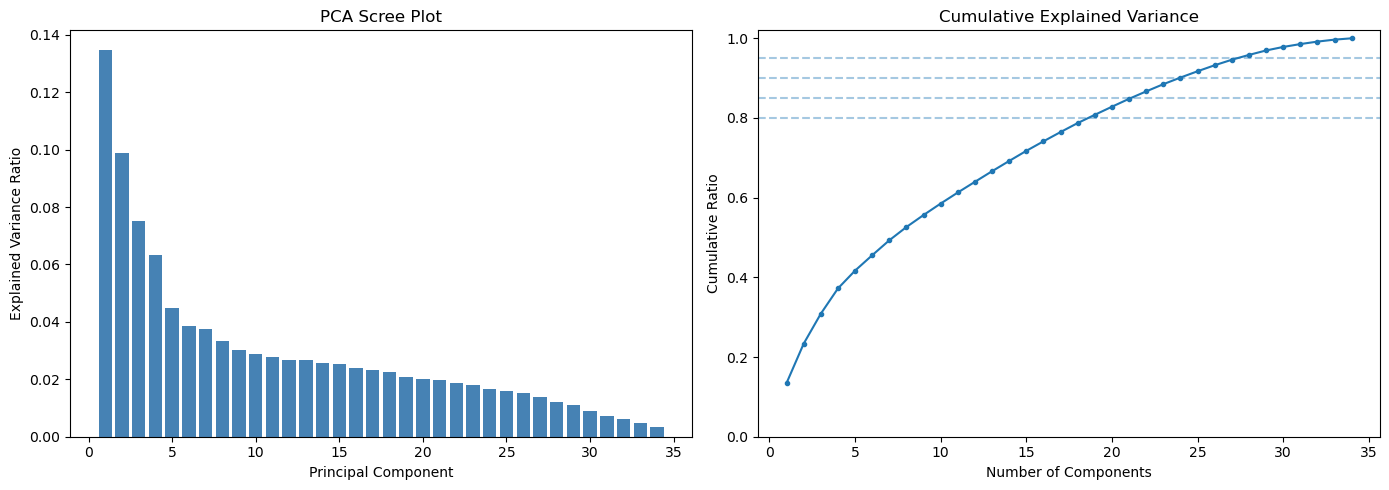

In [10]:
# 차원 축소 효과 확인
components = np.arange(1, len(vif_cols) + 1)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].bar(components, pca.explained_variance_ratio_, color='steelblue')
axes[0].set(title='PCA Scree Plot', xlabel='Principal Component', ylabel='Explained Variance Ratio')
axes[1].plot(components, cumulative_variance, marker='o', markersize=3)
for threshold in thresholds:
    axes[1].axhline(threshold, linestyle='--', alpha=0.4)
axes[1].set(title='Cumulative Explained Variance', xlabel='Number of Components', ylabel='Cumulative Ratio', ylim=(0, 1.02))
plt.tight_layout()
plt.show()

## 3. PCA 검토 결과 해석

- 누적 설명분산 80%에는 19개, 85%에는 22개, 90%에는 24개, 95%에는 28개 주성분이 필요합니다. 90%는 수학적으로 정해진 최적값이 아니라 비교용 기준입니다.
- 90% 기준에서 34개가 24개로 줄어 압축 효과가 크지 않습니다. 현재 34개 변수는 VIF 검토를 통과했고 모델링에 과도한 수가 아니므로 PCA를 필수 전처리로 적용할 필요는 낮습니다.
- 각 주성분은 특정 원본 컬럼을 삭제한 결과가 아니라 원본 34개 변수 전체의 가중합입니다. PCA를 적용하면 관리비 항목별 영향 해석이 어려워집니다.
- K-means에서는 PCA가 거리 계산의 중복·노이즈를 줄일 수 있지만 필수는 아닙니다. **표준화한 원본 변수 K-means와 PCA K-means를 동일한 조건에서 비교**하고 군집 품질과 안정성이 실제로 개선될 때만 PCA를 채택합니다.
- 단지 유형을 군집화하려면 월별 133,380행을 그대로 사용하지 않고, 먼저 2,223개 단지(아파트만) 단위의 평균·변동성·추세 특성으로 집계해야 합니다.

# 4. 1단계 구조 군집 변수 준비

향후 K-Means로 "조건이 비슷한 단지"를 묶으려면 규모·연식·시설 관련 변수가 필요하다. `세대수`는 단지가 몇 세대인지는 알려주지만 "세대 하나가 얼마나 큰가"는 담지 못한다. 이를 보완하기 위해 `평균전용면적`(= 주거전용면적(단지합계) ÷ 세대수) 파생변수를 단지 단위로 계산한다.

**2026-08-31 팀 결정**: 4개 주요 부동산 플랫폼(네이버부동산·KB부동산·호갱노노·리치고)의 공통 검색 필터가 면적·세대수·연식 3가지뿐이라는 점에 근거해, 원래 후보 7개 변수 중 `최고층수`·`지하층수`를 제외한 **5개 변수**로 1단계 구조 군집을 구성하기로 결정한다.

- **트레이드오프 확인**: 사전에 7변수 vs 5변수로 k=5 군집을 직접 비교한 결과, 실루엣은 0.176에서 0.215로 개선되지만 두 군집 배정 간 Adjusted Rand Index는 0.384에 그쳐 개별 단지의 소속 군집 중 상당수가 바뀐다. VIF에서 이미 최고층수·지하층수는 승강기·주차 밀도와 다중공선성이 없다고 확인된 바 있어(VIF 4.30 이하), 이 두 변수가 승강기·주차 밀도만으로는 잡히지 않는 건물 높이·지하 규모 고유 정보를 담고 있었기 때문으로 해석된다.
- 이 트레이드오프를 인지한 상태에서, 플랫폼 공통 기준과의 정합성 및 서비스 설명 용이성을 우선해 5개 변수 채택을 확정한다. 상세 근거: [의사결정 로그](https://app.notion.com/p/3cd831afe08781c4a37ceab265a71ce2)

In [11]:
# 세대수·주거전용면적(단지합계)은 단지별 고정값이므로 단지 단위로 축약한 뒤 계산 (아파트만 필터링된 상태)
complex_df = per_df[['단지코드', '세대수', '주거전용면적(단지합계)']].drop_duplicates('단지코드').reset_index(drop=True)
complex_df['평균전용면적'] = complex_df['주거전용면적(단지합계)'] / complex_df['세대수']

print(f"단지 단위 데이터 크기: {complex_df.shape}")
complex_df.describe()

단지 단위 데이터 크기: (2223, 4)


,세대수,주거전용면적(단지합계),평균전용면적
count,2223.000000,2223.000000,2223.000000
mean,644.946919,49603.828724,78.130480
std,662.399026,55531.206350,22.804515
min,110.000000,2565.952000,13.795441
25%,252.000000,18790.928500,70.849899
50%,435.000000,33008.820000,79.609560
75%,782.500000,58927.165000,85.634857
max,9510.000000,734780.750000,228.950100


In [12]:
# `평균전용면적`을 per_df(월별, 아파트만)에도 추가 — 원본 소스 컬럼이 이미 row-level로 존재하므로 직접 계산
per_df['평균전용면적'] = per_df['주거전용면적(단지합계)'] / per_df['세대수']

print(f"per_df 크기: {per_df.shape}")
per_df[['단지코드', '세대수', '주거전용면적(단지합계)', '평균전용면적']].head()

per_df 크기: (133380, 54)


,단지코드,세대수,주거전용면적(단지합계),평균전용면적
0,A11005401,744.0,94981.45,127.663239
1,A11005401,744.0,94981.45,127.663239
2,A11005401,744.0,94981.45,127.663239
3,A11005401,744.0,94981.45,127.663239
4,A11005401,744.0,94981.45,127.663239


## 4-1. 5개 변수 분포 확인 (왜도, 극단값)

1단계 구조 군집 후보 5개 변수(`세대수`, `평균전용면적`, `사용연수`, `승강기대수_perm2`, `총주차대수_perm2`)를 단지 단위로 정리하고, 각 변수의 왜도(skewness)와 IQR 기준 극단값 개수를 확인합니다. (1-1절의 세대수 보정과 비아파트 단지 제외가 모두 반영된 상태입니다.)

In [13]:
STEP1_COLS = ['세대수', '평균전용면적', '사용연수', '승강기대수_perm2', '총주차대수_perm2']
unit_df = per_df.groupby('단지코드')[STEP1_COLS].mean()

def count_iqr_outliers(s):
    q1, q3 = s.quantile([.25, .75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    return int(((s < lower) | (s > upper)).sum())

dist_summary = pd.DataFrame({
    '평균': unit_df.mean(),
    '표준편차': unit_df.std(),
    '왜도': unit_df.skew(),
    '최솟값': unit_df.min(),
    '최댓값': unit_df.max(),
})
dist_summary['IQR기준_극단값_개수'] = [count_iqr_outliers(unit_df[c]) for c in STEP1_COLS]

print(f"단지 단위 데이터 크기: {unit_df.shape}")
dist_summary

단지 단위 데이터 크기: (2223, 5)


,평균,표준편차,왜도,최솟값,최댓값,IQR기준_극단값_개수
세대수,644.946919,662.399026,3.862171,110.000000,9510.000000,165
평균전용면적,78.130480,22.804515,0.497869,13.795441,228.950100,395
사용연수,22.136484,9.544573,0.035550,1.174949,52.237828,17
승강기대수_perm2,0.000290,0.000141,4.194749,0.000000,0.002623,106
총주차대수_perm2,0.010168,0.003046,0.961399,0.002889,0.039218,29


# 5. 이상치 처리

**원칙**: 데이터 오류로 확인된 값만 수정/제외하고, 실제 극단 단지는 유지한다(임의로 잘라내면 대형·노후 단지처럼 실제로 존재하는 특성이 왜곡된다). 심한 왜도는 변환을 검토한다.

## 5-1. 데이터 오류 확인

4-1절에서 확인한 5개 변수 각각에 대해 극단값을 실제로 들여다보고 오류 여부를 판단한다.

| 변수 | 확인한 내용 | 판단 |
|---|---|---|
| 세대수 | 1-1절에서 이미 전수 검증(83개 불일치 → 82개 보정) 완료. 보정 후 남은 상위값(헬리오시티 9,510세대, 잠실파크리오 6,864세대, 잠실엘스 5,678세대 등)을 아래 코드로 재확인 | 전부 실존하는 초대형 단지 — **오류 아님, 유지** |
| 평균전용면적 | 세대수 보정 및 1-1절의 A13881302 면적정보 오류 수정 반영 후 상위값(나인원 한남 229㎡, 방배3차e편한세상 212㎡, 청암자이 202㎡ 등)을 아래 코드로 확인 | 전부 실존하는 대형 평형·고급 단지 — **오류 아님, 유지** |
| 사용연수 | 왜도 0.04로 거의 대칭, 극단값 비율도 낮음(17개) | 별도 처리 불필요 |
| 승강기대수_perm2 | 상위값(왕십리 KCC스위첸 등)을 아래 코드로 확인 | 승강기 대수 자체는 정상 범위이고 관리비부과면적이 작아 밀도가 높게 나온 것 — **오류 아님, 유지**. 0인 단지 13개도 저층 소규모 단지라 승강기 미설치가 자연스러움 |
| 총주차대수_perm2 | 상위값(임대단지 다수)·하위값(압구정 현대, 삼호 등 노후 대단지)을 아래 코드로 확인 | 임대단지의 주차 배정 기준 차이, 노후 대단지의 실제 주차난을 반영한 값 — **오류 아님, 유지** |

5개 변수 모두 오류가 아닌 것으로 확인되어 별도 수정 없이 다음 단계로 진행한다. (최고층수·지하층수를 후보에서 제외하면서, 지난 지하층수 데이터 오류(A13986701, 21→9) 건은 이번 파이프라인에서는 해당하지 않는다.)

In [14]:
# 위 표의 판단 근거: 극단값 상위 단지들이 실제로 존재하는 단지인지 이름으로 확인
info_cols = ['단지코드', '단지명', '세대수', '평균전용면적', '승강기대수_perm2', '총주차대수_perm2']
info = per_df[info_cols].drop_duplicates('단지코드')

print("[세대수 상위 5]")
print(info.sort_values('세대수', ascending=False).head(5)[['단지명', '세대수']].to_string(index=False))

print("\n[평균전용면적 상위 5]")
print(info.sort_values('평균전용면적', ascending=False).head(5)[['단지명', '세대수', '평균전용면적']].to_string(index=False))

print("\n[승강기대수_perm2 상위 5]")
print(info.sort_values('승강기대수_perm2', ascending=False).head(5)[['단지명', '승강기대수_perm2']].to_string(index=False))

print("\n[총주차대수_perm2 상위 5 / 하위 5]")
print(info.sort_values('총주차대수_perm2', ascending=False).head(5)[['단지명', '총주차대수_perm2']].to_string(index=False))
print(info.sort_values('총주차대수_perm2').head(5)[['단지명', '총주차대수_perm2']].to_string(index=False))

[세대수 상위 5]
        단지명    세대수
   헬리오시티아파트 9510.0
     잠실파크리오 6864.0
    잠실엘스아파트 5678.0
      잠실리센츠 5563.0
올림픽선수기자촌아파트 5540.0

[평균전용면적 상위 5]
      단지명   세대수     평균전용면적
   나인원 한남 341.0 228.950100
방배3차e편한세상 192.0 211.602188
     청암자이 170.0 201.715176
   워커힐아파트 576.0 189.760920
     한남더힐 600.0 187.723242

[승강기대수_perm2 상위 5]
             단지명  승강기대수_perm2
서울 왕십리 KCC스위첸아파트     0.002623
   서울수목원현대홈타운스위트     0.001797
        면목경남아너스빌     0.001286
       개포4차현대아파트     0.001218
        도봉숲 아뜨리움     0.001190

[총주차대수_perm2 상위 5 / 하위 5]
             단지명  총주차대수_perm2
서울 왕십리 KCC스위첸아파트     0.039218
          아스하임4차     0.033054
      백련산힐스테이트임대     0.030249
         래미안용두1차     0.025634
      길음뉴타운4단지임대     0.024515
              단지명  총주차대수_perm2
               삼호     0.002889
             안암대광     0.003259
             천호금호     0.003649
           광장극동1차     0.003722
압구정 현대(10,13,14차)     0.003927


## 5-2. 변환 (심한 왜도 보정)

`사용연수`(왜도 0.04, 거의 대칭)를 제외한 4개 변수는 왜도가 1을 넘거나 그에 준하게 치우쳐 있다. 아래 변환은 0과 음수를 포함해도 적용 가능하고(로그 변환과 달리 0 이하 값에서도 동작), 변환과 동시에 평균 0·표준편차 1로 표준화까지 해준다.

In [15]:
from sklearn.preprocessing import PowerTransformer

TRANSFORM_COLS = ['세대수', '평균전용면적', '승강기대수_perm2', '총주차대수_perm2']

before_skew = unit_df.skew()
before_outliers = {c: count_iqr_outliers(unit_df[c]) for c in STEP1_COLS}

pt = PowerTransformer()
unit_df_transformed = unit_df.copy()
unit_df_transformed[TRANSFORM_COLS] = pt.fit_transform(unit_df[TRANSFORM_COLS])

after_skew = unit_df_transformed.skew()
after_outliers = {c: count_iqr_outliers(unit_df_transformed[c]) for c in STEP1_COLS}

comparison = pd.DataFrame({
    '왜도_변환전': before_skew,
    '왜도_변환후': after_skew,
    'IQR극단값_변환전': pd.Series(before_outliers),
    'IQR극단값_변환후': pd.Series(after_outliers),
})
comparison

,왜도_변환전,왜도_변환후,IQR극단값_변환전,IQR극단값_변환후
세대수,3.862171,0.074547,165,0
평균전용면적,0.497869,0.160728,395,405
사용연수,0.035550,0.035550,17,17
승강기대수_perm2,4.194749,-0.072265,106,32
총주차대수_perm2,0.961399,-0.052748,29,20


**결과 해석**
- 4개 변수(`세대수`, `평균전용면적`, `승강기대수_perm2`, `총주차대수_perm2`)에 변환을 적용하자 왜도가 대부분 0에 가깝게(좌우 대칭에 가깝게) 개선됐다(세대수 3.86→0.07, 승강기대수_perm2 4.19→-0.07).
- IQR 기준 극단값 개수도 대부분 크게 줄었다(세대수 165→0, 승강기대수_perm2 106→32, 총주차대수_perm2 29→20). `평균전용면적`은 왜도 자체는 줄었지만(0.50→0.16) IQR 극단값은 오히려 소폭 늘었다(395→405) — 단봉이 아닌 분포 형태 때문으로 보인다.
- `unit_df_transformed`는 `사용연수`를 제외한 4개 변수가 이미 표준화(평균 0·표준편차 1)까지 완료된 상태다. `사용연수`는 별도로 `StandardScaler`를 적용해 합치면 1단계 K-Means 입력이 된다.

# 6. 표준화

`unit_df_transformed`는 `사용연수`를 제외한 4개 변수가 이미 표준화(평균 0·표준편차 1)까지 끝난 상태다. `사용연수`는 왜도가 낮아 변환 없이 `StandardScaler`만 적용해 나머지 4개와 같은 스케일로 맞춘다.

In [16]:
X = unit_df_transformed.copy()
X['사용연수'] = StandardScaler().fit_transform(unit_df[['사용연수']])
X = X[STEP1_COLS]

print(f"표준화 완료: {X.shape}")
X.describe()

표준화 완료: (2223, 5)


,세대수,평균전용면적,사용연수,승강기대수_perm2,총주차대수_perm2
count,2.223000e+03,2.223000e+03,2.223000e+03,2.223000e+03,2.223000e+03
mean,-4.717774e-15,-2.205463e-16,-1.789941e-16,-1.853868e-16,-8.949706e-17
std,1.000225e+00,1.000225e+00,1.000225e+00,1.000225e+00,1.000225e+00
min,-2.449101e+00,-3.100728e+00,-2.196667e+00,-4.239419e+00,-2.876971e+00
25%,-8.191579e-01,-2.951577e-01,-6.340743e-01,-6.552694e-01,-6.972373e-01
50%,2.818184e-02,8.977948e-02,5.437462e-02,-7.307605e-02,2.222295e-01
75%,7.781851e-01,3.504256e-01,6.221764e-01,6.212324e-01,5.982089e-01
max,2.703868e+00,5.955894e+00,3.154475e+00,3.111144e+00,5.405091e+00


# 7. K-Means 실행 (k=2~10)

`k=2`부터 `10`까지 각각 K-Means를 실행하고 관성(inertia)·Silhouette·Davies-Bouldin·Calinski-Harabasz와 군집 크기를 함께 기록한다. `n_init=50`은 서로 다른 초기 중심점으로 50번 시도해 그중 가장 좋은(관성이 가장 낮은) 결과를 채택한다는 뜻이고, `random_state=42`는 그 초기화 난수를 고정해 재실행해도 같은 결과가 나오게 한다.

In [17]:
from sklearn.cluster import KMeans
from sklearn.metrics import (
    adjusted_rand_score,
    calinski_harabasz_score,
    davies_bouldin_score,
    silhouette_score,
)

k_search_rows = []
for k in range(2, 11):
    km = KMeans(n_clusters=k, n_init=50, random_state=42)
    labels = km.fit_predict(X)
    sizes = pd.Series(labels).value_counts().sort_index()
    k_search_rows.append({
        'k': k,
        'inertia': km.inertia_,
        'silhouette': silhouette_score(X, labels),
        'davies_bouldin': davies_bouldin_score(X, labels),
        'calinski_harabasz': calinski_harabasz_score(X, labels),
        '최소_군집크기': sizes.min(),
        '최대_군집크기': sizes.max(),
        '군집크기_표준편차': sizes.std(),
    })

k_search = pd.DataFrame(k_search_rows)
k_search

,k,inertia,silhouette,davies_bouldin,calinski_harabasz,최소_군집크기,최대_군집크기,군집크기_표준편차
0,2,8282.740882,0.244086,1.559676,759.466802,874,1349,335.875721
1,3,7076.759353,0.211425,1.541318,633.403920,687,801,57.236352
2,4,6288.137695,0.212813,1.533014,567.778462,274,765,213.734064
3,5,5572.136050,0.215099,1.397039,551.588526,262,646,141.254380
4,6,5139.593214,0.204657,1.377457,515.506823,253,498,80.743421
5,7,4786.266124,0.210998,1.318049,488.358215,82,478,124.585790
6,8,4447.109341,0.216815,1.314848,474.445523,80,425,112.443557
7,9,4143.972469,0.221168,1.268349,465.551324,77,394,113.841996
8,10,3886.552263,0.225370,1.268867,457.319203,77,398,117.957667


# 8. 평가지표 해석과 엘보우

Silhouette·Calinski-Harabasz는 k=2에서 가장 높고 k=6까지는 k가 커질수록 낮아지는 경향을 보인다(k=6 이후로는 5변수 기준 소폭 다시 오르지만 k=2 수준을 넘지 못한다). **다만 이 지표들은 k가 작을수록 유리해지는 구조적 편향이 있다** — 군집이 2개뿐이면 "가장 뚜렷한 경계선 하나"만 찾으면 되기 때문이다. 절대값으로도 k=2의 Silhouette(약 0.24)은 관례적 해석 기준(Kaufman & Rousseeuw)으로 "뚜렷한 구조 없음~약한 구조"의 경계에 불과해 강한 근거가 되지 못한다.

이런 편향이 없는 기준으로 **엘보우(Elbow)** 방식을 추가로 확인한다. 관성(각 단지-자기 군집 중심 거리 제곱합)은 k가 늘어날수록 항상 줄어들기 때문에, 그래프의 첫 점과 끝 점을 잇는 직선에서 가장 멀리 떨어진 점("팔꿈치")을 수치로 찾는다(Kneedle 방식).

엘보우(Kneedle 방식) 추천 k = 5


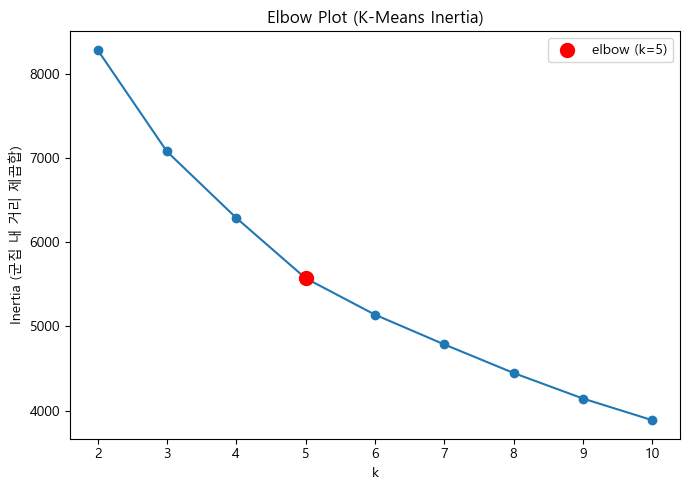

In [18]:
def find_elbow_k(k_metrics):
    k = k_metrics['k'].to_numpy(dtype=float)
    inertia = k_metrics['inertia'].to_numpy(dtype=float)
    k_norm = (k - k.min()) / (k.max() - k.min())
    inertia_norm = (inertia - inertia.min()) / (inertia.max() - inertia.min())
    x1, y1 = k_norm[0], inertia_norm[0]
    x2, y2 = k_norm[-1], inertia_norm[-1]
    distances = np.abs((y2 - y1) * k_norm - (x2 - x1) * inertia_norm + x2 * y1 - y2 * x1) / np.hypot(y2 - y1, x2 - x1)
    return int(k[int(np.argmax(distances))])

elbow_k = find_elbow_k(k_search)
print(f"엘보우(Kneedle 방식) 추천 k = {elbow_k}")

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(k_search['k'], k_search['inertia'], marker='o')
elbow_row = k_search[k_search['k'] == elbow_k].iloc[0]
ax.scatter([elbow_k], [elbow_row['inertia']], color='red', s=100, zorder=5, label=f'elbow (k={elbow_k})')
ax.legend()
ax.set(title='Elbow Plot (K-Means Inertia)', xlabel='k', ylabel='Inertia (군집 내 거리 제곱합)')
ax.set_xticks(k_search['k'])
plt.tight_layout()
plt.show()

# 9. 초기값 안정성 확인

Silhouette이 작은 k에 유리하다는 편향을 감안해, "실루엣 상위 몇 개"가 아니라 **k=2~10 전체**에 대해 시드(무작위 초기화 기준값)를 0~9로 10번 바꿔 K-Means를 반복 실행하고, 서로 다른 시드 결과끼리 **Adjusted Rand Index(ARI)**로 재현성을 확인한다. ARI가 1에 가까울수록 "시드를 바꿔도 거의 항상 같은 군집이 나온다"는 뜻이다.

In [19]:
def stability_check(X, k, seeds=range(10), n_init=50):
    runs = [KMeans(n_clusters=k, n_init=n_init, random_state=seed).fit_predict(X) for seed in seeds]
    aris = [adjusted_rand_score(runs[i], runs[j]) for i in range(len(runs)) for j in range(i + 1, len(runs))]
    return {
        'k': k,
        '쌍별_ARI_평균': float(np.mean(aris)),
        '쌍별_ARI_최소': float(np.min(aris)),
        '쌍별_ARI_최대': float(np.max(aris)),
    }

stability = pd.DataFrame([stability_check(X, k) for k in k_search['k']])
stability

,k,쌍별_ARI_평균,쌍별_ARI_최소,쌍별_ARI_최대
0,2,0.998718,0.996395,1.00000
1,3,0.997538,0.993077,1.00000
2,4,0.992577,0.982080,1.00000
3,5,0.982871,0.967891,0.99599
4,6,0.988824,0.975507,1.00000
5,7,0.993820,0.983965,1.00000
6,8,0.976566,0.931668,1.00000
7,9,0.991538,0.978883,1.00000
8,10,0.994128,0.986959,1.00000


# 10. 결과 정리 — 최종 k 선택

**선정 기준**: (1) 안정성(쌍별 ARI 평균 0.9 이상)을 통과하는 k만 후보로 남긴다. (2) 그 안에서는 Silhouette 대신 **엘보우**를 우선한다 — Silhouette·Calinski-Harabasz는 안정적인 후보들 사이에서도 여전히 작은 k에 유리해서, 순위를 매기는 기준으로 쓰기엔 편향이 있기 때문이다.

5변수 기준으로는 k=2~10 전 구간이 안정성 기준을 통과한다(쌍별 ARI 평균 최저값도 k=8의 0.977로 여전히 0.9를 크게 웃돈다) — 최고층수·지하층수가 빠지면서 7변수 때(k=8~10에서 0.81~0.85로 급락) 나타났던 불안정 구간이 사라졌다. 따라서 안정성만으로는 후보를 좁힐 수 없어 엘보우를 그대로 따른다.

**k=4와 k=5 비교**: 엘보우는 k=5를 가리키고, 실루엣도 k=4(0.213)보다 k=5(0.215)가 근소하게 높다. 다만 개별 단지 군집 배정을 직접 대조하면 7변수 때와 다른 양상이 나타난다 — k=4의 4개 군집 중 1개("노후·소형평형·대단지", 274개)만 95%가 k=5에서도 그대로 유지되고, 나머지 3개는 승강기·주차 밀도를 기준으로 다시 갈라진다. 예를 들어 "대형·신축"(667개)의 60%는 대형평형 위주 군집으로, 40%는 시설밀도가 가장 높은 군집으로 나뉜다. 최고층수·지하층수가 빠지면서 군집을 가르는 축이 7변수 때만큼 뚜렷하지 않다는 신호이지만, 최소 군집 크기(k=5 기준 262개)도 통계적으로 충분히 크고 엘보우·실루엣 모두 k=5를 지지하므로 k=5를 최종 채택한다.

k=2(신축/구축 2분류)는 지나치게 거칠어 실질적 비교군으로 쓰기 어렵다.

In [20]:
final_k = 5
final_km = KMeans(n_clusters=final_k, n_init=50, random_state=42)
final_labels = final_km.fit_predict(X)

unit_df_with_cluster = unit_df.copy()
unit_df_with_cluster['cluster'] = final_labels

cluster_profile = unit_df_with_cluster.groupby('cluster')[STEP1_COLS].mean()
cluster_profile['단지_수'] = unit_df_with_cluster.groupby('cluster').size()
print(f"최종 k = {final_k}")
cluster_profile

최종 k = 5


,세대수,평균전용면적,사용연수,승강기대수_perm2,총주차대수_perm2,단지_수
cluster,,,,,,
0,917.800412,91.101093,19.441553,0.000219,0.011169,486
1,231.092879,80.199621,21.916936,0.000316,0.010648,646
2,1024.729008,43.968088,28.335084,0.000206,0.006973,262
3,664.639474,90.499513,34.463679,0.000249,0.006850,380
4,706.766147,70.580214,11.319554,0.000413,0.013065,449


## 10-1. 군집 시각화 (원 변수 축)

이번 K-Means는 PCA 경로와 비교하지 않고 원본 5개 변수(세대수·평균전용면적·사용연수·승강기대수_perm2·총주차대수_perm2)로만 실행했다(9절 결론). 따라서 시각화도 PC1/PC2 같은 합성 축 대신, 11번 항목의 군집 이름을 정의한 원 변수를 그대로 축으로 쓴다 — 세대수x평균전용면적(규모x평형), 세대수x사용연수(규모x연식) 두 쌍으로 3개 핵심 축을 모두 확인한다.

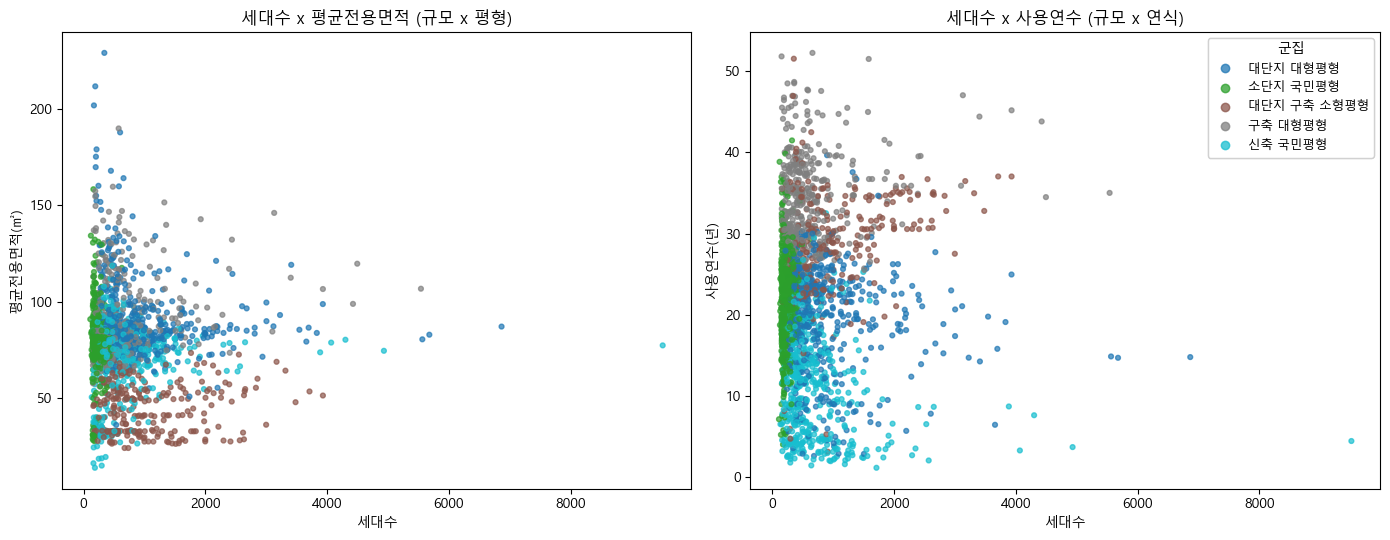

In [21]:
# PCA 축(PC1/PC2) 대신, 군집 이름을 정의한 원 변수를 그대로 축으로 사용 (10-1절 참고)
CLUSTER_NAMES = {
    0: '대단지 대형평형', 1: '소단지 국민평형', 2: '대단지 구축 소형평형',
    3: '구축 대형평형', 4: '신축 국민평형',
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

sc1 = axes[0].scatter(unit_df_with_cluster['세대수'], unit_df_with_cluster['평균전용면적'],
                       c=final_labels, cmap='tab10', s=12, alpha=0.7)
axes[0].set(title='세대수 x 평균전용면적 (규모 x 평형)', xlabel='세대수', ylabel='평균전용면적(㎡)')

sc2 = axes[1].scatter(unit_df_with_cluster['세대수'], unit_df_with_cluster['사용연수'],
                       c=final_labels, cmap='tab10', s=12, alpha=0.7)
axes[1].set(title='세대수 x 사용연수 (규모 x 연식)', xlabel='세대수', ylabel='사용연수(년)')
handles, labels = sc2.legend_elements()
labels = [CLUSTER_NAMES[i] for i in range(len(handles))]
legend = axes[1].legend(handles, labels, title='군집', loc='best', fontsize=9)
axes[1].add_artist(legend)

plt.tight_layout()
plt.show()

**군집 해석 및 명명** (군집 번호는 재실행 환경에 따라 바뀔 수 있어 특성으로 구분한다):

클러스터링 결과, 규모(세대수)·평형(평균전용면적)·연식(사용연수) 3축의 실측값을 기준으로 다음 5개 유형이 나뉘었고, 팀에서 아래와 같이 명명하기로 확정했다(2026-08-31):

| 원 분류 기준 (규모·평형·연식 실측값) | 최종 명칭 | 단지 수 |
|---|---|---:|
| 대단지(917.8) · 대형평형(91.10㎡) · 준신축(19.44년) | **대단지 대형평형** | 486 |
| 소단지(231.1) · 중형평형(80.20㎡) · 준신축(21.92년) | **소단지 국민평형** | 646 (최대 군집) |
| 대단지(1024.7) · 소형평형(43.97㎡) · 구축(28.34년) | **대단지 구축 소형평형** | 262 (최소 군집) |
| 중단지(664.6) · 대형평형(90.50㎡) · 재건축 연한(34.46년, 30년 초과) | **구축 대형평형** | 380 |
| 중단지(706.8) · 중형평형(70.58㎡) · 신축(11.32년) | **신축 국민평형** | 449 |

(규모·평형 분류 구간: 소단지 <400 / 중단지 400~800 / 대단지 800+세대, 소형평형 <60 / 중형평형 60~85 / 대형평형 85㎡+. 연식은 재건축 연한(서울시 공동주택 재건축 연한 통상 30년) 기준까지 반영해 신축 <15년 / 준신축 15~25년 / 구축 25~30년 / 재건축 연한 30년+ 4단계로 나눴다. "국민평형"은 국민주택규모(전용 85㎡ 이하) 통념을 반영한 소비자 인지용 표현이다. 상세 근거: `dugong-개인작업/클러스터링/5변수_7변수_군집_비교표_20260831.md`)

Silhouette이 약 0.22 수준이라는 것은 군집 사이의 자연적 경계가 아주 강하지는 않다는 뜻이다(최고층수·지하층수를 포함한 7변수 버전의 약 0.18보다는 다소 높다). 따라서 이 5개 군집을 데이터에 존재하는 절대적·유일한 유형으로 보기보다는, **후속 관리비 벤치마킹을 위해 정의한 운영상 유사 단지군**으로 해석한다.

**다음 단계**: 각 군집 내부에서 관리비 수준을 비교해 "같은 유형 안에서 관리비가 유독 높은 단지"를 찾고, 운영방식(관리방식·난방방식)·지역 조건을 추가해 실제 비교 가능한 단지를 최종 선별한다. 이번 결과는 원본 변수 K-Means만 실행한 것으로, PCA 경로와의 비교는 진행하지 않았다.